                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

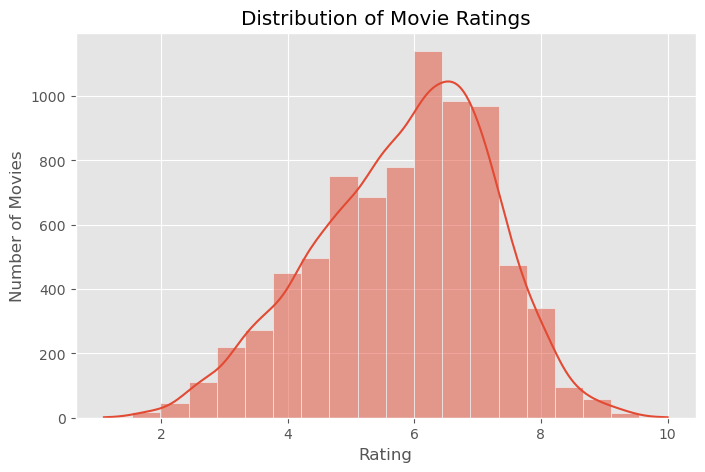

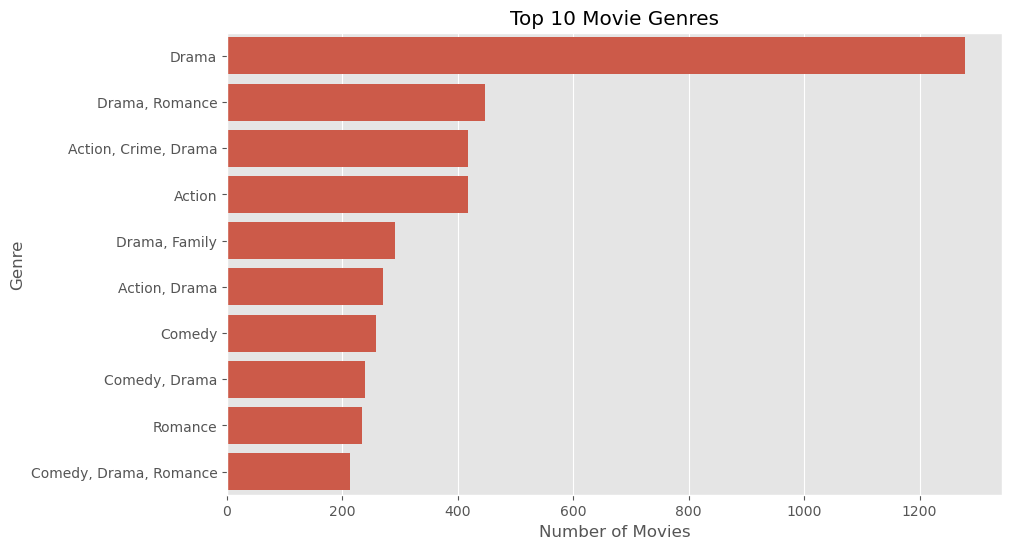

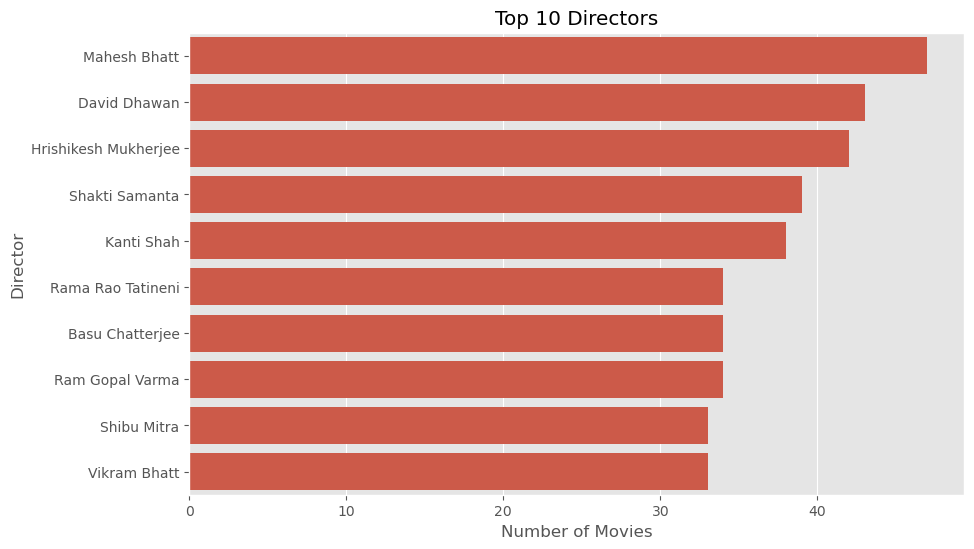

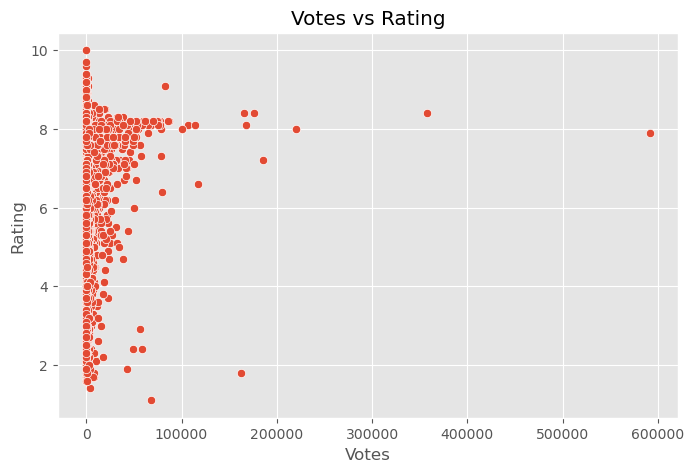

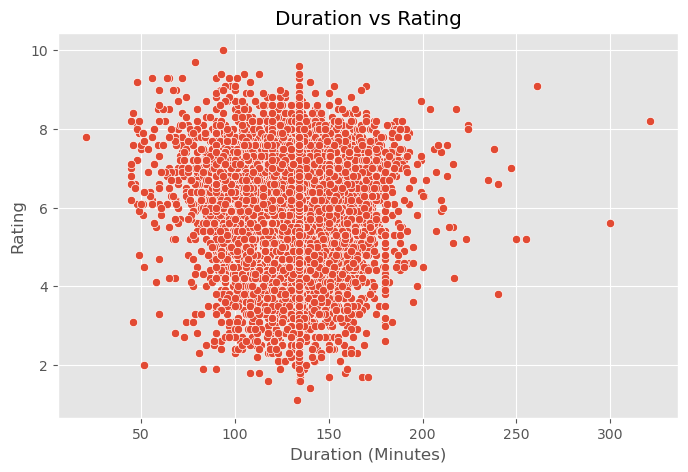

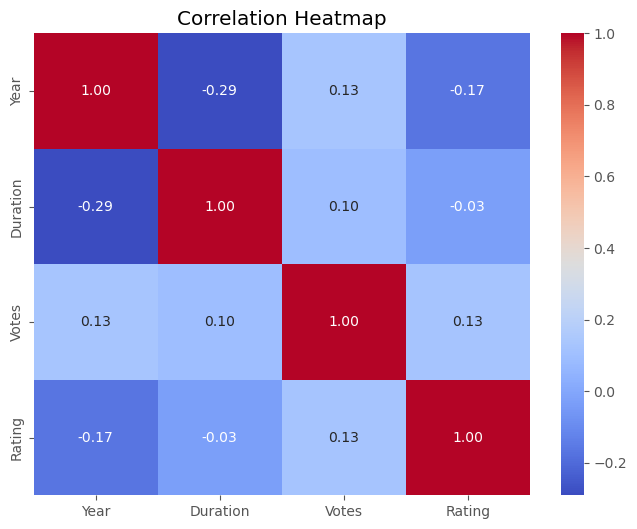


Top 10 Highest Rated Movies:

                      Name  Rating
8339       Love Qubool Hai    10.0
5410            Half Songs     9.7
2563                 Breed     9.6
11704             Ram-Path     9.4
14222  The Reluctant Crime     9.4
6852                  June     9.4
5077          Gho Gho Rani     9.4
1314          Ashok Vatika     9.3
5125           God of gods     9.3
12673   Secrets of Sinauli     9.3


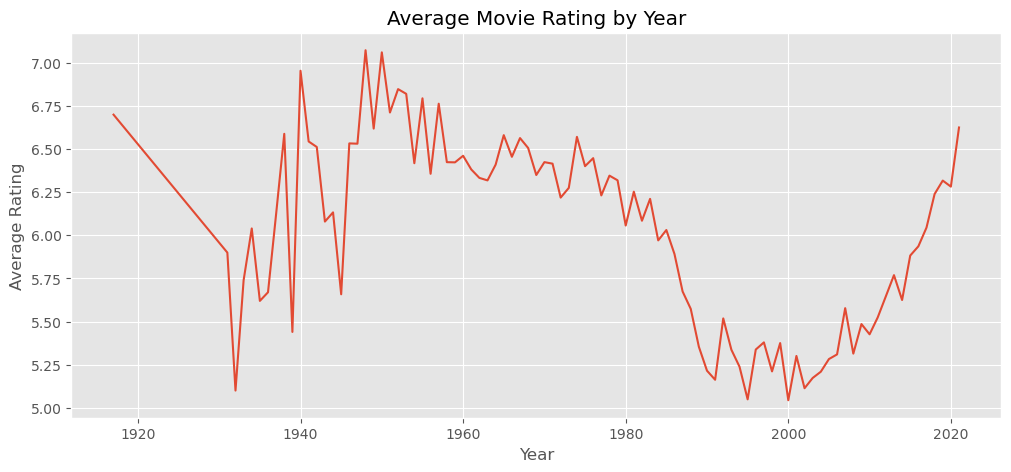


First 5 Rows After Encoding:

                                 Name  Year  Duration  Genre  Rating  Votes  \
1  #Gadhvi (He thought he was Gandhi)  2019       109    268     7.0      8   
3                             #Yaaram  2019       110    207     4.4     35   
5                ...Aur Pyaar Ho Gaya  1997       147    177     4.7    827   
6                           ...Yahaan  2005       142    331     7.4   1086   
8                  ?: A Question Mark  2012        82    367     5.6    326   

   Director  Actor 1  Actor 2  Actor 3  
1       811     1782     2815      377  
3      1749     1589      890     2572  
5      2005      508       85     2449  
6      2643      931     1388     3030  
8       174     2521     1461     1205  

Shape of X : (7919, 8)
Shape of y : (7919,)

Training Data Shape
(6335, 8)
(6335,)

Testing Data Shape
(1584, 8)
(1584,)

Training Features
       Year  Duration  Votes  Genre  Director  Actor 1  Actor 2  Actor 3
8157   2019        74     10    17

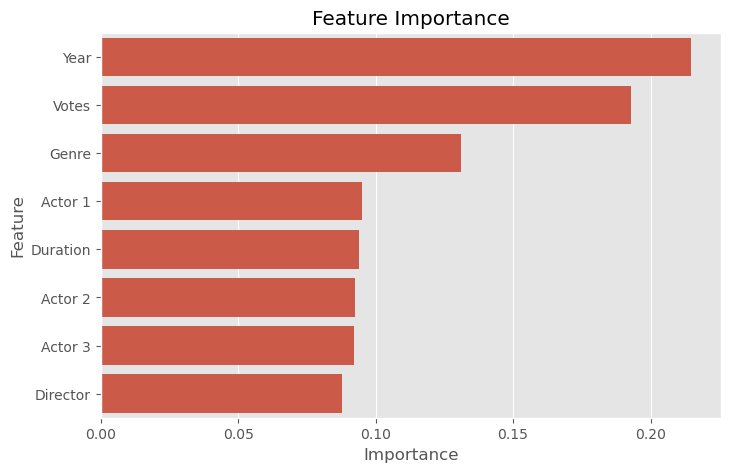


Model Saved Successfully!


In [6]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save Model
import pickle

# Load Dataset
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

# Display first 5 rows
print(df.head())

# Display last 5 rows
print(df.tail())

# Dataset Shape
print("\nDataset Shape:")
print(df.shape)

# Column Names
print("\nColumn Names:")
print(df.columns)

# Dataset Information
print("\nDataset Info:")
df.info()

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

# Missing Values Before Cleaning
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# Remove rows where Rating is missing
# (Target variable)
df = df.dropna(subset=['Rating'])

# Clean Year Column
df['Year'] = df['Year'].astype(str)
df['Year'] = df['Year'].str.extract(r'(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Clean Duration Column
df['Duration'] = df['Duration'].astype(str)
df['Duration'] = df['Duration'].str.replace(' min', '', regex=False)
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

# Clean Votes Column
df['Votes'] = df['Votes'].astype(str)
df['Votes'] = df['Votes'].str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')


# Fill Missing Numeric Values
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

# Convert to Integer
df['Year'] = df['Year'].astype(int)
df['Duration'] = df['Duration'].astype(int)
df['Votes'] = df['Votes'].astype(int)

# Fill Missing Categorical Values
df['Genre'] = df['Genre'].fillna(df['Genre'].mode()[0])

df['Director'] = df['Director'].fillna("Unknown")

df['Actor 1'] = df['Actor 1'].fillna("Unknown")

df['Actor 2'] = df['Actor 2'].fillna("Unknown")

df['Actor 3'] = df['Actor 3'].fillna("Unknown")

# Verify Cleaning
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows After Cleaning:")
print(df.head())

# Exploratory Data Analysis (EDA)

# Set plot style
plt.style.use('ggplot')

# Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.show()

# Top 10 Movie Genres
plt.figure(figsize=(10,6))

top_genres = df['Genre'].value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

# Top 10 Directors
plt.figure(figsize=(10,6))

top_directors = df['Director'].value_counts().head(10)

sns.barplot(x=top_directors.values, y=top_directors.index)

plt.title("Top 10 Directors")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.show()

# Rating vs Votes
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='Votes', y='Rating')

plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

# Rating vs Duration
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='Duration', y='Rating')

plt.title("Duration vs Rating")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Rating")
plt.show()

# Correlation Heatmap

numeric_df = df[['Year', 'Duration', 'Votes', 'Rating']]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Top 10 Highest Rated Movies

top_movies = df[['Name', 'Rating']].sort_values(
    by='Rating',
    ascending=False
).head(10)

print("\nTop 10 Highest Rated Movies:\n")
print(top_movies)

# Average Rating by Year

year_rating = df.groupby('Year')['Rating'].mean()

plt.figure(figsize=(12,5))

year_rating.plot()

plt.title("Average Movie Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.show()

# Feature Encoding

# Create LabelEncoder object
label_encoder = LabelEncoder()

# List of categorical columns
categorical_columns = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

# Apply Label Encoding
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Display first 5 rows after encoding
print("\nFirst 5 Rows After Encoding:\n")
print(df.head())

# Create Features and Target

# Features (Independent Variables)
X = df[['Year',
        'Duration',
        'Votes',
        'Genre',
        'Director',
        'Actor 1',
        'Actor 2',
        'Actor 3']]

# Target (Dependent Variable)
y = df['Rating']

print("\nShape of X :", X.shape)
print("Shape of y :", y.shape)

# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape")
print(X_train.shape)
print(y_train.shape)

print("\nTesting Data Shape")
print(X_test.shape)
print(y_test.shape)

print("\nTraining Features")
print(X_train.head())

print("\nTraining Target")
print(y_train.head())

# Chapter 6 : Build Random Forest Model

# Create Random Forest Regressor
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
        n_jobs=-1

)
# Train the model
model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

# Predict Ratings

y_pred = model.predict(X_test)

print("\nFirst 10 Predicted Ratings:")
print(y_pred[:10])

# Model Evaluation

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("\n========== Model Performance ==========")
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R2 Score : {r2:.3f}")

# Compare Actual vs Predicted

comparison = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": y_pred
})

print("\nActual vs Predicted Ratings:")
print(comparison.head(10))

# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

# Save Model

with open("movie_rating_prediction.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nModel Saved Successfully!")
